In [2]:
import random
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image

import mlflow

PROJECT_ROOT = Path.cwd().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT))

from src.data.cityscapes_mapping import map_mask_to_groups
from src.inference.cityseg_infer import run_inference

In [5]:
MODEL_PATH = f"{PROJECT_ROOT}/models/unet_baseline_best.keras"

model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

print("Model loaded.")

E0000 00:00:1772707810.692473   29525 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1772707810.698013   29525 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model loaded.


In [8]:
manifest = pd.read_csv(f"{PROJECT_ROOT}/data/manifests/cityscapes_pairs.csv")

val_df = manifest[manifest["split"] == "val"]

print(len(val_df))
val_df.head()

500


,split,city,image_path,mask_path
2975,val,frankfurt,leftImg8bit/val/frankfurt/frankfurt_000000_000...,gtFine/val/frankfurt/frankfurt_000000_000294_g...
2976,val,frankfurt,leftImg8bit/val/frankfurt/frankfurt_000000_000...,gtFine/val/frankfurt/frankfurt_000000_000576_g...
2977,val,frankfurt,leftImg8bit/val/frankfurt/frankfurt_000000_001...,gtFine/val/frankfurt/frankfurt_000000_001016_g...
2978,val,frankfurt,leftImg8bit/val/frankfurt/frankfurt_000000_001...,gtFine/val/frankfurt/frankfurt_000000_001236_g...
2979,val,frankfurt,leftImg8bit/val/frankfurt/frankfurt_000000_001...,gtFine/val/frankfurt/frankfurt_000000_001751_g...


In [9]:
samples = val_df.sample(6, random_state=42)

samples

,split,city,image_path,mask_path
3336,val,munster,leftImg8bit/val/munster/munster_000035_000019_...,gtFine/val/munster/munster_000035_000019_gtFin...
3048,val,frankfurt,leftImg8bit/val/frankfurt/frankfurt_000001_009...,gtFine/val/frankfurt/frankfurt_000001_009854_g...
3349,val,munster,leftImg8bit/val/munster/munster_000048_000019_...,gtFine/val/munster/munster_000048_000019_gtFin...
3130,val,frankfurt,leftImg8bit/val/frankfurt/frankfurt_000001_043...,gtFine/val/frankfurt/frankfurt_000001_043395_g...
3079,val,frankfurt,leftImg8bit/val/frankfurt/frankfurt_000001_019...,gtFine/val/frankfurt/frankfurt_000001_019854_g...
3369,val,munster,leftImg8bit/val/munster/munster_000068_000019_...,gtFine/val/munster/munster_000068_000019_gtFin...


In [10]:
output_dir = Path("outputs/visual_validation")
output_dir.mkdir(parents=True, exist_ok=True)

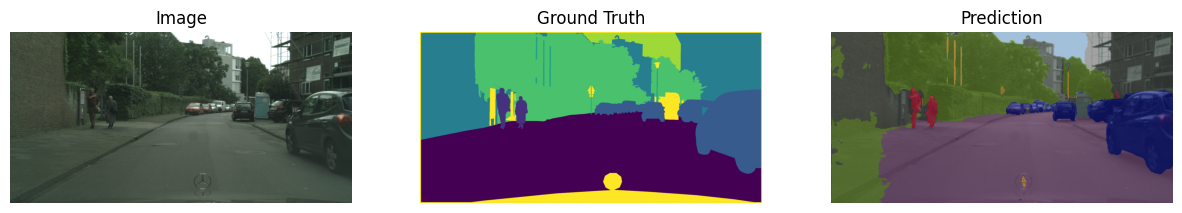

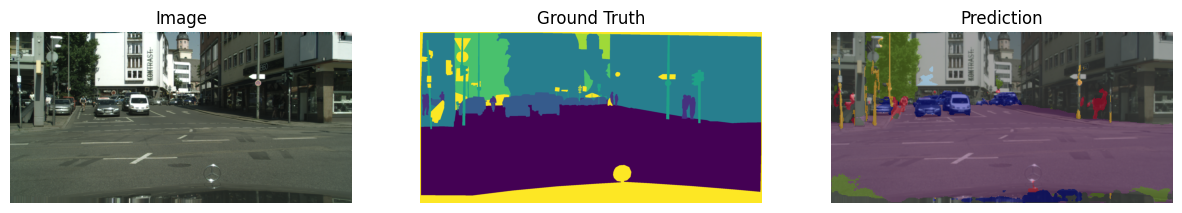

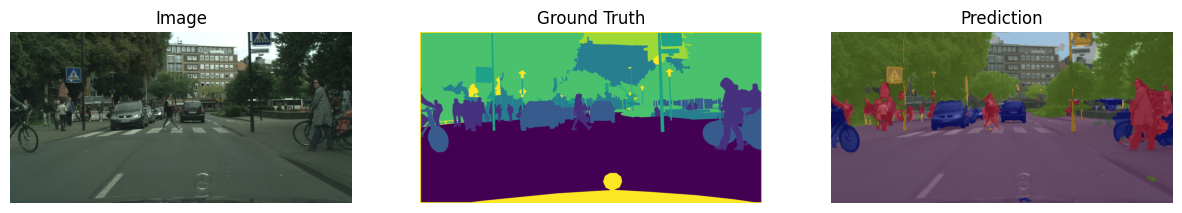

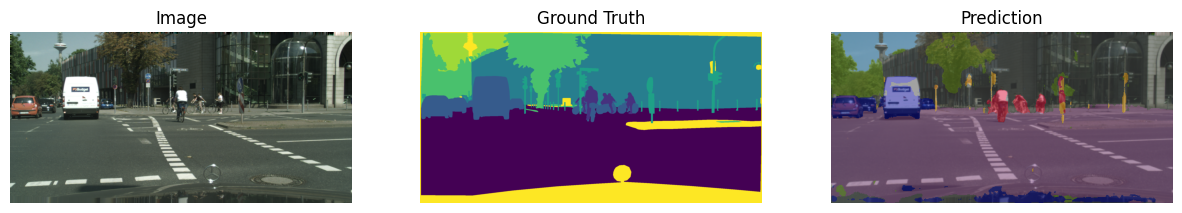

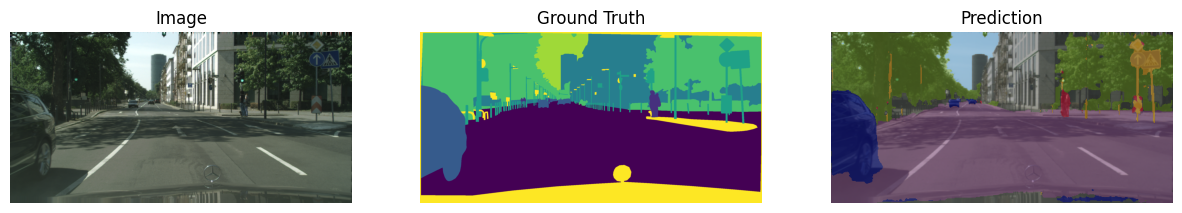

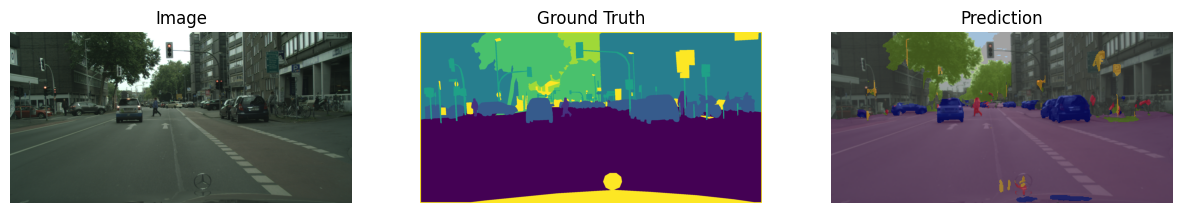

In [12]:
logged_images = []

for idx, row in samples.iterrows():
    
    img_path = Path(f"{PROJECT_ROOT}/data") / row["image_path"]
    mask_path = Path(f"{PROJECT_ROOT}/data") / row["mask_path"]

    result = run_inference(
        model_path=MODEL_PATH,
        image_path=img_path,
        out_dir=output_dir
    )

    overlay_path = result["overlay_path"]
    
    logged_images.append(overlay_path)

    # affichage
    img = np.array(Image.open(img_path))
    gt = np.array(Image.open(mask_path))
    gt = map_mask_to_groups(gt)

    pred_overlay = np.array(Image.open(overlay_path))

    fig, axes = plt.subplots(1,3, figsize=(15,5))

    axes[0].imshow(img)
    axes[0].set_title("Image")

    axes[1].imshow(gt)
    axes[1].set_title("Ground Truth")

    axes[2].imshow(pred_overlay)
    axes[2].set_title("Prediction")

    for ax in axes:
        ax.axis("off")

    plt.show()

In [13]:
with mlflow.start_run(run_name="visual_validation_baseline"):

    for img_path in logged_images:
        mlflow.log_artifact(img_path)

2026/03/05 11:54:09 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/05 11:54:09 INFO mlflow.store.db.utils: Updating database tables
